In [1]:
import torch
import torch.distributions as dist
import matplotlib.pyplot as plt
import seaborn as sns

## Metropolis Monte-Carlo Sampling

In [67]:
import time
from samplers.metropolis_sampler import MetropolisSampler

def make_gaussian_mean_model(samples, prior_dist, like_cov = None):

    like_cov = torch.eye(samples.shape[-1]) if like_cov is None else like_cov

    def log_prob(params):
        prior_lp = prior_dist.log_prob(params)
        like = dist.MultivariateNormal(params, like_cov)
        like_lp = like.log_prob(samples.unsqueeze(1)).sum(dim=0)
        return prior_lp + like_lp
    
    return log_prob

## Generate Synthetic Data
n_samples = 5000
base_dist = dist.MultivariateNormal(
    loc=torch.Tensor([1, 4]), 
    covariance_matrix=torch.eye(2)
)

samples = base_dist.sample((n_samples,))

prior = dist.MultivariateNormal(torch.tensor([-1.0, 6.0]), 10.0 * torch.eye(2))
model = make_gaussian_mean_model(samples, prior)
sampler = MetropolisSampler(
    model, 
    dim=2, 
    proposal_std=0.03, 
    init_dist=prior, 
    seed=0
)

num_iters, num_chains, burnin = 50000, 10, 25000


start_time = time.perf_counter()
sampler.run(num_iters=num_iters, num_chains=num_chains, burnin=burnin)
end_time = time.perf_counter()
print(end_time - start_time)

265.20986209996045


In [ ]:
## set up acceptance rate so that we can tune the algo
## set up wall clock recorder so that we can calculate ess / time
## select plots to model different features. Arviz looks like it has some good built-ins
## what to do for a 200 + variable model?

In [80]:
sampler.results.diagnostics['accept'].to(torch.float).mean(dim = 0)

tensor([0.2751, 0.2754, 0.2760, 0.2773, 0.2761, 0.2729, 0.2757, 0.2744, 0.2737,
        0.2715])

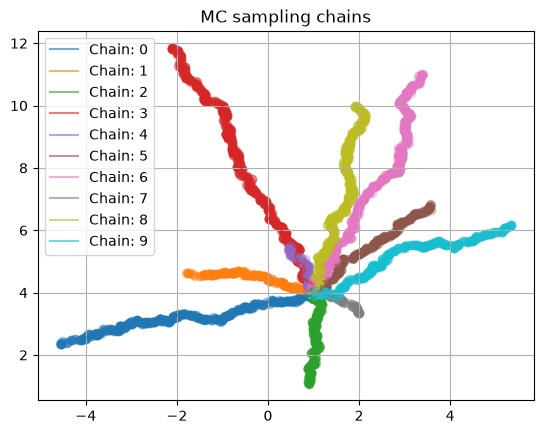

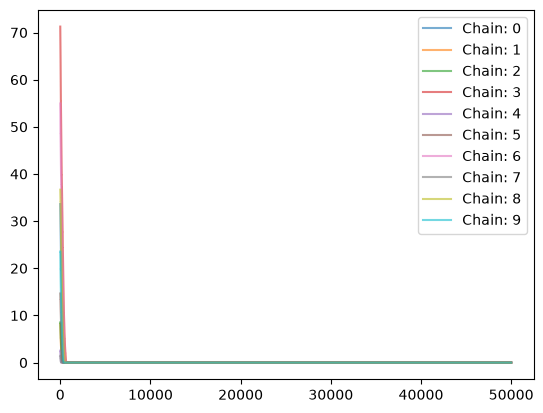

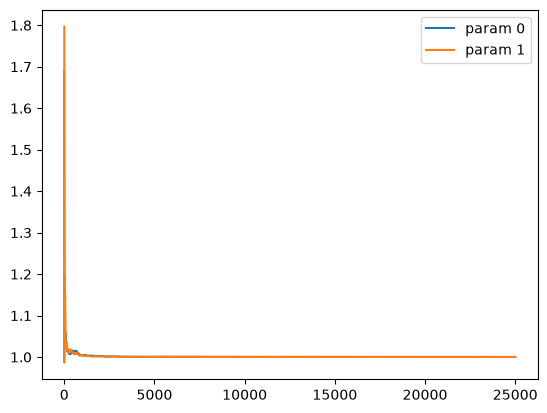

In [68]:
from samplers.base_sampler import SamplerResults

def plot_gelman_rubin(results: SamplerResults):
    num_params = results.gelman_rubin.size()[-1]
    to_plot = results.gelman_rubin.numpy()
    for p in range(num_params):
        plt.plot(to_plot[:, p], label=f"param {p}")
    plt.legend()
    plt.show()

def plot_error_rate(results: SamplerResults, num_chains: int, true_params: torch.Tensor):
    params = results.params
    for c in range(num_chains):
        to_plot = params[c, :, :]
        error = ((to_plot - true_params).numpy()**2).sum(axis=1)
        plt.plot(error, label = f"Chain: {c}", alpha = 0.6)

    plt.legend()
    plt.show();

def plot_2d_convergence(results: SamplerResults, num_chains:int):
    params = results.params
    for c in range(num_chains):
        to_plot = params[c, :, :].numpy()
        plt.plot(to_plot[:, 0], to_plot[:, 1], alpha = .6, label = f"Chain: {c}")
        plt.scatter(to_plot[:, 0], to_plot[:, 1],  alpha = .3)
        plt.grid(True)

    plt.title("MC sampling chains")
    plt.legend()
    plt.show();

plot_2d_convergence(sampler.results, num_chains)
plot_error_rate(sampler.results, num_chains, true_params=torch.Tensor([1, 4]))
plot_gelman_rubin(sampler.results)

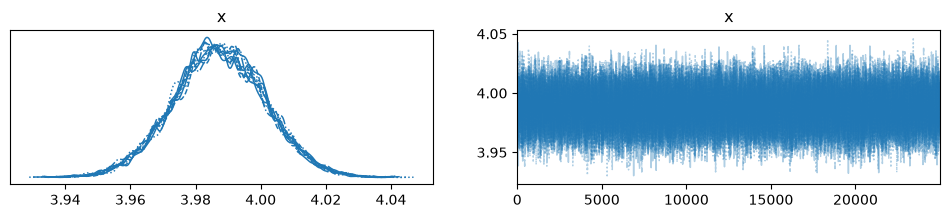

In [89]:
import arviz as ar
r = sampler.results
idata = ar.convert_to_inference_data(r.params[: ,(r.burnin + 1):, 1])
ar.plot_trace(idata);

array([<Axes: title={'center': 'x\n0'}, xlabel='Total number of draws', ylabel='ESS'>,
       <Axes: title={'center': 'x\n1'}, xlabel='Total number of draws', ylabel='ESS'>],
      dtype=object)

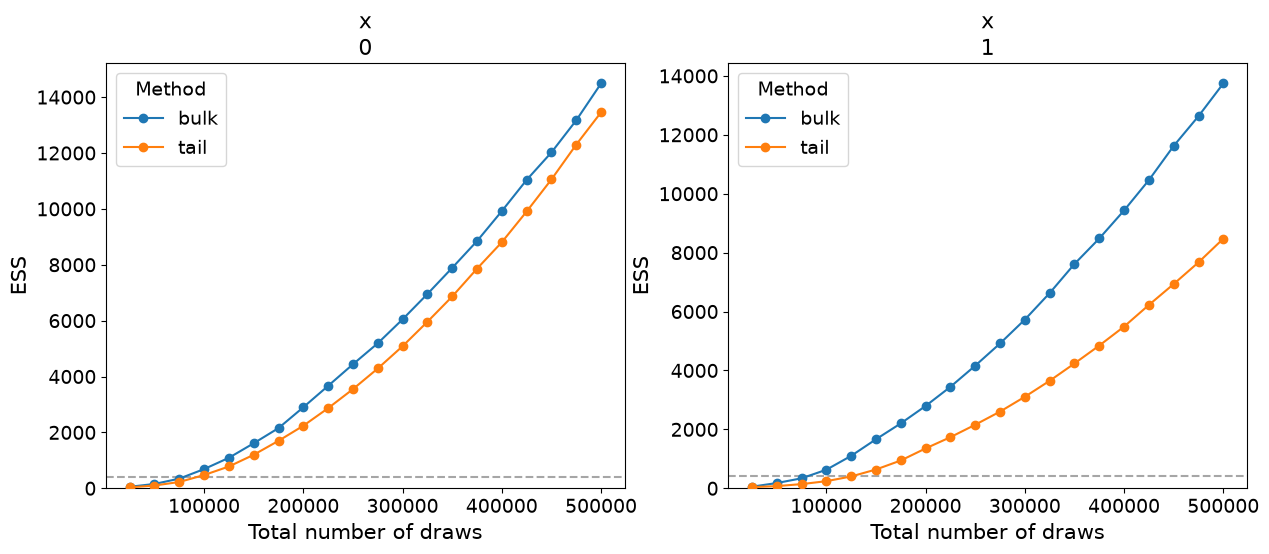

In [70]:


ar.plot_ess(idata = sampler.results.params, kind="evolution")

array([<Axes: title={'center': 'x\n0'}, xlabel='Quantile', ylabel='MCSE for quantiles'>,
       <Axes: title={'center': 'x\n1'}, xlabel='Quantile', ylabel='MCSE for quantiles'>],
      dtype=object)

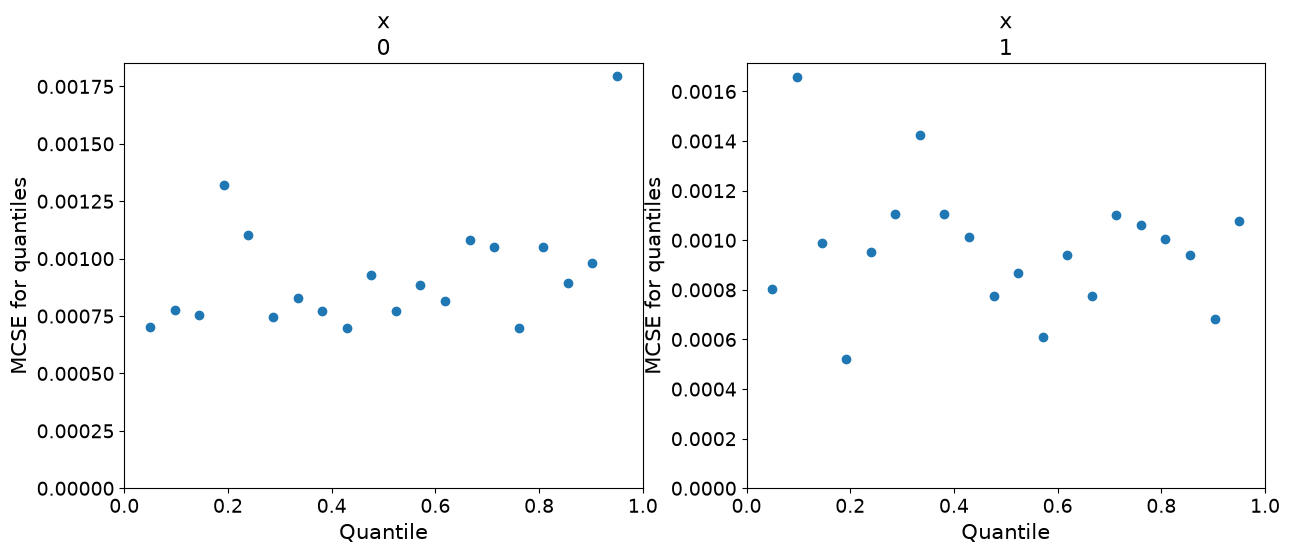

In [49]:
ar.plot_mcse(idata)

array([<Axes: title={'center': 'theta\n0'}, xlabel='Quantile', ylabel='ESS for small intervals'>,
       <Axes: title={'center': 'theta\n1'}, xlabel='Quantile', ylabel='ESS for small intervals'>],
      dtype=object)

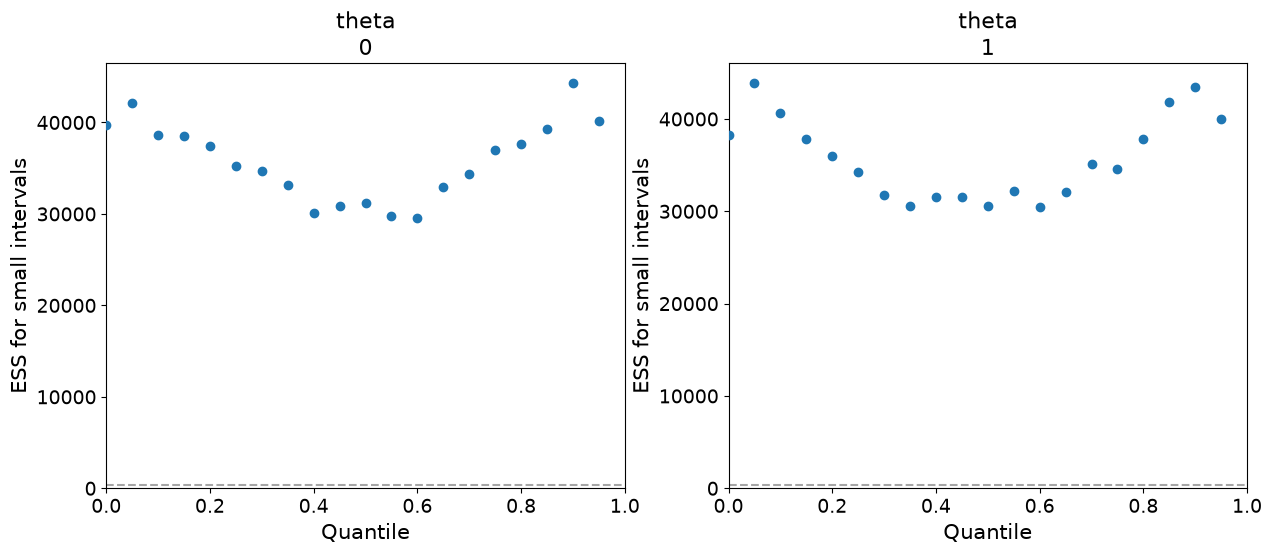

In [84]:
import arviz as az

r = sampler.results
# drop the initial state + burnin so ESS reflects the kept draws
draws = r.params[:, r.burnin + 1:, :].cpu().numpy()   # (chain, draw, dim)

idata = az.from_dict(posterior={"theta": draws})
az.plot_ess(idata, var_names=["theta"])

In [81]:
ar.ess(r.params)

<xarray.Dataset> Size: 32B
Dimensions:  (x_dim_0: 2)
Coordinates:
  * x_dim_0  (x_dim_0) int64 16B 0 1
Data variables:
    x        (x_dim_0) float64 16B 1.449e+04 1.374e+04
Attributes:
    created_at:     2026-06-26T09:44:40.801660+00:00
    arviz_version:  0.23.4

In [86]:
idata

Inference data with groups:
	> posterior

In [88]:
torch.Tensor(ar.ess(idata)["theta"].values) / 260

tensor([122.0982, 120.5909])

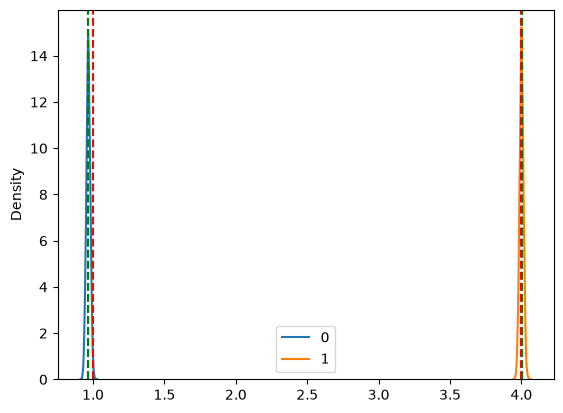

In [ ]:
results_to_plot =  sampler.results.reshape(num_chains * burnin, 2).numpy()
sns.kdeplot(
    data = results_to_plot
)
plt.axvline(x = results_to_plot[:,0].mean(), linestyle = '--')
plt.axvline(x = results_to_plot[:,1].mean(), linestyle = '--')
plt.axvline(x = 1.0, c = 'red', linestyle = '--')
plt.axvline(x = 4.0, c = 'red', linestyle = '--')
plt.axvline(x = samples[:,0].mean().numpy(), c = 'green', linestyle = '--')
plt.axvline(x = samples[:,1].mean().numpy(), c = 'green', linestyle = '--')

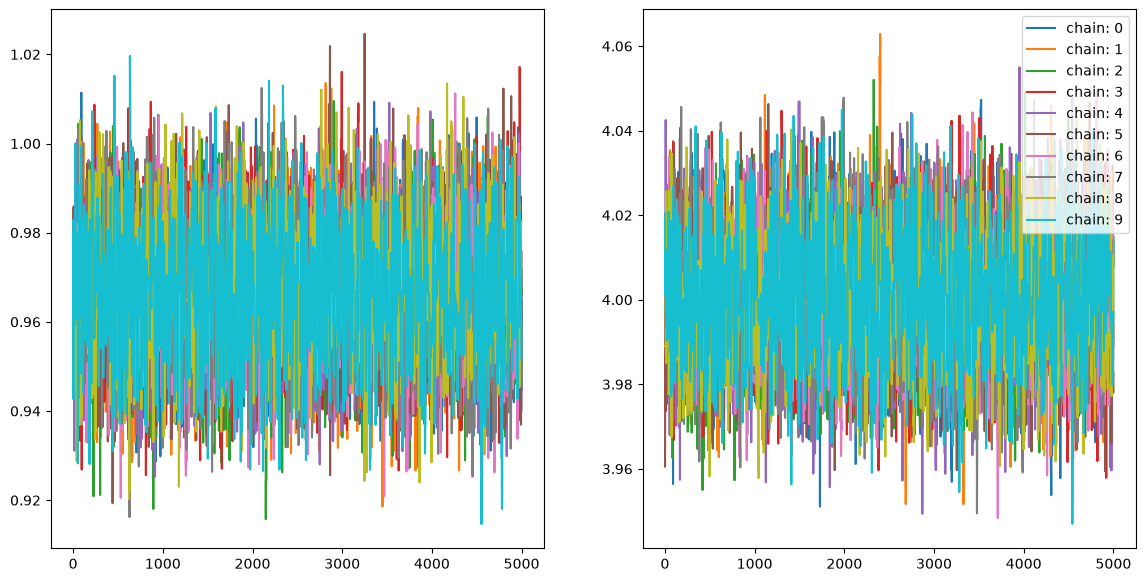

In [ ]:
fig, ax = plt.subplots(1, 2, figsize = (14, 7))
for c in range(num_chains):
    to_plot = sampler.results[c, :, :].numpy()
    ax[0].plot(to_plot[:, 0], label = f"chain: {c}")
    ax[1].plot(to_plot[:, 1], label = f"chain: {c}")

plt.legend()
plt.show();


In [ ]:
## monte carlo standard errors

monte_carlo_standard_errors = torch.sqrt(torch.pow(sampler.results - sampler.results.mean(dim=(0,1)), 2).sum(dim=(0,1)) / (num_chains - 1)) / torch.sqrt(torch.Tensor([num_chains]))

tensor([0.3334, 0.3345])

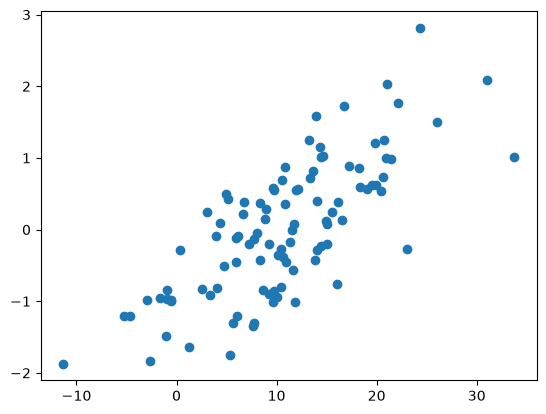

In [ ]:
beta0 = 10
beta1 = 5
x = torch.randn(size=(n_samples,))
y = dist.Normal(loc=beta0 + beta1 * x, scale=5)
samples = torch.stack([y.sample(),x], dim=1)
plt.scatter(samples.numpy()[:,0], samples.numpy()[:,1])


In [ ]:
def make_gaussian_lr_model(samples, prior_dist, scale = None):

    scale = 1.0 if scale is None else scale

    def log_prob(params):
        prior_lp = prior_dist.log_prob(params).sum(dim=-1)
        like = dist.Normal(params[:, 0].unsqueeze(1) + params[:, 1].unsqueeze(1) * samples[:,1], scale)
        like_lp = like.log_prob(samples[:, 0]).sum(dim=-1)
        return prior_lp + like_lp
    
    return log_prob

prior = dist.Normal(torch.tensor([0.,0.]), torch.tensor([10.,10.]))
model = make_gaussian_lr_model(samples, prior)
sampler = MetropolisSampler(
    model, 
    dim=2, 
    proposal_std=0.05, 
    init_dist=prior, 
    seed=0
)
history = sampler.run(num_iters=1000, num_chains=10)
print(sampler.acceptance_rate)   # tune proposal_std toward ~0.2–0.4

tensor([0.5210, 0.5410, 0.5220, 0.5280, 0.6700, 0.6900, 0.6530, 0.5990, 0.6970,
        0.6640])


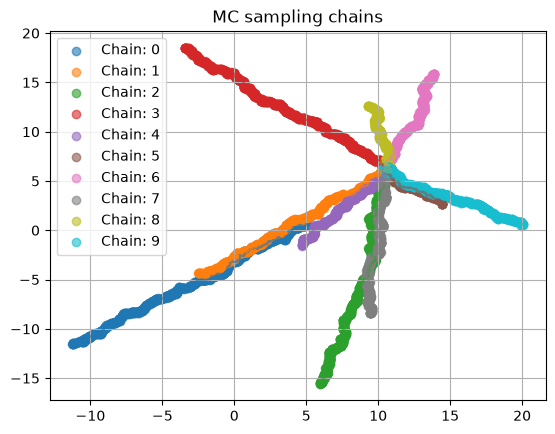

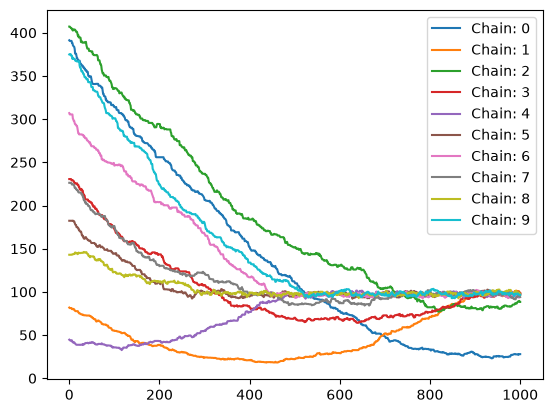

In [ ]:
plot_2d_convergence(history, num_chains)
plot_error_rate(history, num_chains)